In [29]:
import os
from pathlib import Path
import pandas as pd
import pysam
from icecream import ic
import numpy as np
from tqdm import tqdm

import sys
from pathlib import Path
# Add nuctool directory to path for imports
nuctool_path = Path.cwd().parent / 'nuctool'
if str(nuctool_path) not in sys.path:
    sys.path.insert(0, str(nuctool_path))
from Plotter import Plotter

from ChromatinFibers import (
    convert_to_footprints,
    fetch_chromosome_sequence,
    ChromatinFiber,
    compute_vanderlick,
)

from Plotter import Plotter, plot_sequence, plot_footprints
from pycorrelate import pcorrelate

plot = Plotter()
FILEOUT = rf"figures/SimulateYeastFibers.jpg"

# Create the directory if it doesn't exist
output_dir = os.path.dirname(FILEOUT)
if output_dir and not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

In [30]:
filename = "occupancy_locus(chrII:273000-283000)"
occupancy = np.load(f"methylation_occupancy/{filename}.npy")
def extract_locus(locus_txt):
    locus_txt = locus_txt.replace(',', '')
    parts = locus_txt.split(':')
    chrom = parts[0]
    start, end = map(int, parts[1].split('-'))
    return (chrom, start, end)

locus = extract_locus(filename.lstrip("occupancy_locus(").rstrip(")"))
chrom, start, end = locus

In [31]:
chrom_number = chrom.lstrip("chr")

chromosome = fetch_chromosome_sequence(r".genomes/sacCer3/sacCer3.fa", chromosome=chrom_number)
length = end-start + 2000
#locus_start = np.random.randint(0, len(chromosome) - length)
locus_start = start - 1000
locus_end = locus_start + length
#locus_sequence = chromosome[-10001 : -1]
locus_sequence = chromosome[locus_start : locus_end]
fiber = ChromatinFiber(sequence=locus_sequence,start = locus_start)
fiber.fetch_orfs_by_range(start=locus_start, end=locus_end, chromosome=chrom_number)

Selected chromosome: .genomes/sacCer3, chrII  len=813184


In [32]:
import numpy as np
from scipy.signal import find_peaks, correlate
from scipy.interpolate import interp1d
from scipy.fft import rfft
from scipy.optimize import differential_evolution


# ── Metrics ───────────────────────────────────────────────────────────────────

def frfsm(H_A, H_B, sigma_0_db=6.0):
    eps = np.abs(
        10 * np.log10(np.abs(H_A) ** 2 + 1e-20)
        - 10 * np.log10(np.abs(H_B) ** 2 + 1e-20)
    )
    return np.exp(-0.5 * (eps / sigma_0_db) ** 2)


def psm(H_A, H_B, sigma_0_rad=np.pi / 4):
    phase_e = np.unwrap(np.angle(H_A)) - np.unwrap(np.angle(H_B))
    phase_w = np.abs(((phase_e + np.pi) % (2 * np.pi)) - np.pi)
    return np.exp(-0.5 * (phase_w / sigma_0_rad) ** 2)


# ── LFS internals ─────────────────────────────────────────────────────────────

def _find_peaks(arr, min_distance=5):
    idx, _ = find_peaks(arr, distance=min_distance)
    idx = idx[np.argsort(arr[idx])[::-1]]
    return np.sort(idx)


def _lfs_segment(x_log, seg_baseline, seg_comparison, n_interp=1000):
    f_interp = np.linspace(x_log[0], x_log[-1], n_interp)
    interp_b = interp1d(x_log, seg_baseline,   kind='linear', bounds_error=False, fill_value=0.0)
    interp_c = interp1d(x_log, seg_comparison, kind='linear', bounds_error=False, fill_value=0.0)
    b_uniform = interp_b(f_interp)
    c_uniform = interp_c(f_interp)

    corr  = correlate(b_uniform, c_uniform, mode='full')
    lags  = np.arange(-(n_interp - 1), n_interp)
    best  = lags[np.argmax(corr)]
    shift = best * (f_interp[1] - f_interp[0])

    interp_shifted = interp1d(x_log + shift, seg_comparison, kind='linear',
                              bounds_error=False, fill_value=np.nan)
    return interp_shifted(x_log), np.exp(shift)


def _apply_lfs(x, baseline, comparison, min_peak_distance=5, overlap_fraction=0.20):
    x        = np.asarray(x,          dtype=float)
    baseline = np.asarray(baseline,   dtype=float)
    comparison = np.asarray(comparison, dtype=float)
    N      = len(x)
    x_log  = np.log(np.clip(x, 1e-30, None))

    peaks = _find_peaks(baseline, min_distance=min_peak_distance)
    if len(peaks) == 0:
        return comparison.copy(), [1.0], [0, N]

    edges = [0] + [(peaks[i] + peaks[i+1]) // 2
                   for i in range(len(peaks) - 1)] + [N]

    out    = np.full(N, np.nan)
    counts = np.zeros(N)
    taus   = []

    for start, end in zip(edges[:-1], edges[1:]):
        pad     = max(1, int((end - start) * overlap_fraction))
        i_start = max(0, start - pad)
        i_end   = min(N, end   + pad)
        seg_x   = x_log[i_start:i_end]

        if len(seg_x) < 3:
            taus.append(1.0)
            out[i_start:i_end] = comparison[i_start:i_end]
            counts[i_start:i_end] += 1
            continue

        shifted, tau = _lfs_segment(seg_x, baseline[i_start:i_end],
                                           comparison[i_start:i_end])
        taus.append(tau)
        valid = ~np.isnan(shifted)
        out[i_start:i_end][valid]    += shifted[valid]
        counts[i_start:i_end][valid] += 1

    mask = counts > 0
    out[mask] /= counts[mask]
    out[np.isnan(out)] = comparison[np.isnan(out)]
    return out, taus, edges


def _shift_phase(x, phase, taus, edges):
    x_log     = np.log(np.clip(np.asarray(x, dtype=float), 1e-30, None))
    out       = np.copy(phase).astype(float)
    for i, (start, end) in enumerate(zip(edges[:-1], edges[1:])):
        if i >= len(taus):
            break
        shifted_log = x_log[start:end] + np.log(taus[i])
        fn = interp1d(shifted_log, phase[start:end], kind='linear',
                      bounds_error=False, fill_value=np.nan)
        shifted_ph = fn(x_log[start:end])
        valid = ~np.isnan(shifted_ph)
        out[start:end][valid] = shifted_ph[valid]
    return out


# ── Fitting function ──────────────────────────────────────────────────────────



In [33]:
def complex_spectral_fit_frfsm_psm(
    y_data,
    physical_model_func,
    bounds,
    alpha=0.5,
    sigma_db=6.0,
    sigma_rad=np.pi / 4,
    freq_range=(5, 150),
):
    window     = np.hanning(len(y_data))
    H_obs      = rfft(y_data * window)[freq_range[0]:freq_range[1]]
    mag_obs    = np.clip(np.abs(H_obs), 1e-10, None)
    phase_obs  = np.angle(H_obs)
    f_axis     = np.arange(freq_range[0], freq_range[1], dtype=float) + 1.0

    def objective(params):
        try:
            model_sig = physical_model_func(*params)
            H_mod     = rfft(model_sig * window)[freq_range[0]:freq_range[1]]
            mag_mod   = np.clip(np.abs(H_mod), 1e-10, None)
            phase_mod = np.angle(H_mod)

            mag_lfs, taus, edges = _apply_lfs(f_axis, mag_obs, mag_mod)
            mag_lfs              = np.clip(mag_lfs, 1e-10, None)
            phase_lfs            = _shift_phase(f_axis, phase_mod, taus, edges)

            amp_score   = float(np.mean(frfsm(mag_obs, mag_lfs,   sigma_db)))
            phase_score = float(np.mean(psm  (phase_obs, phase_lfs, sigma_rad)))
            return -(alpha * amp_score + (1 - alpha) * phase_score)
        except Exception:
            return 0.0   # return worst score on any failure

    res = differential_evolution(
        objective, bounds, tol=1e-6, strategy='best1bin', disp=True
    )
    return res.x


# ── Your model and call (unchanged) ──────────────────────────────────────────

def model_func(period, amplitude, chemical_potential):
    fiber.calc_energy_landscape(
        octamer=True,
        period=period,
        amplitude=amplitude,
        chemical_potential=chemical_potential,
    )
    return fiber.occupancy[1000:-1000]

bounds = [
    (9.5, 11.0),
    (0.01, 0.19),
    (0, 50),
]

period_fp, amplitude_fp, chemical_potential_fp = complex_spectral_fit_frfsm_psm(
    occupancy, model_func, bounds, alpha=0.1
)
print(f"period={period_fp:.4f}, amplitude={amplitude_fp:.4f}, mu={chemical_potential_fp:.4f}")

differential_evolution step 1: f(x)= -0.588196914422108
differential_evolution step 2: f(x)= -0.5944874509606158
differential_evolution step 3: f(x)= -0.600298061182917
differential_evolution step 4: f(x)= -0.600298061182917
differential_evolution step 5: f(x)= -0.6053448141786884
differential_evolution step 6: f(x)= -0.6053448141786884
differential_evolution step 7: f(x)= -0.6053448141786884
differential_evolution step 8: f(x)= -0.6259215240596918
differential_evolution step 9: f(x)= -0.6259215240596918
differential_evolution step 10: f(x)= -0.6259215240596918
differential_evolution step 11: f(x)= -0.6259215240596918
differential_evolution step 12: f(x)= -0.6293897229730622
differential_evolution step 13: f(x)= -0.6293897229730622
differential_evolution step 14: f(x)= -0.6455847766350193
differential_evolution step 15: f(x)= -0.6455847766350193
differential_evolution step 16: f(x)= -0.6455847766350193
differential_evolution step 17: f(x)= -0.6455847766350193
differential_evolution ste

In [34]:
import matplotlib.pyplot as plt

# period_lsq, amplitude_lsq, chemical_potential_lsq, period_cc, amplitude_cc, chemical_potential_cc

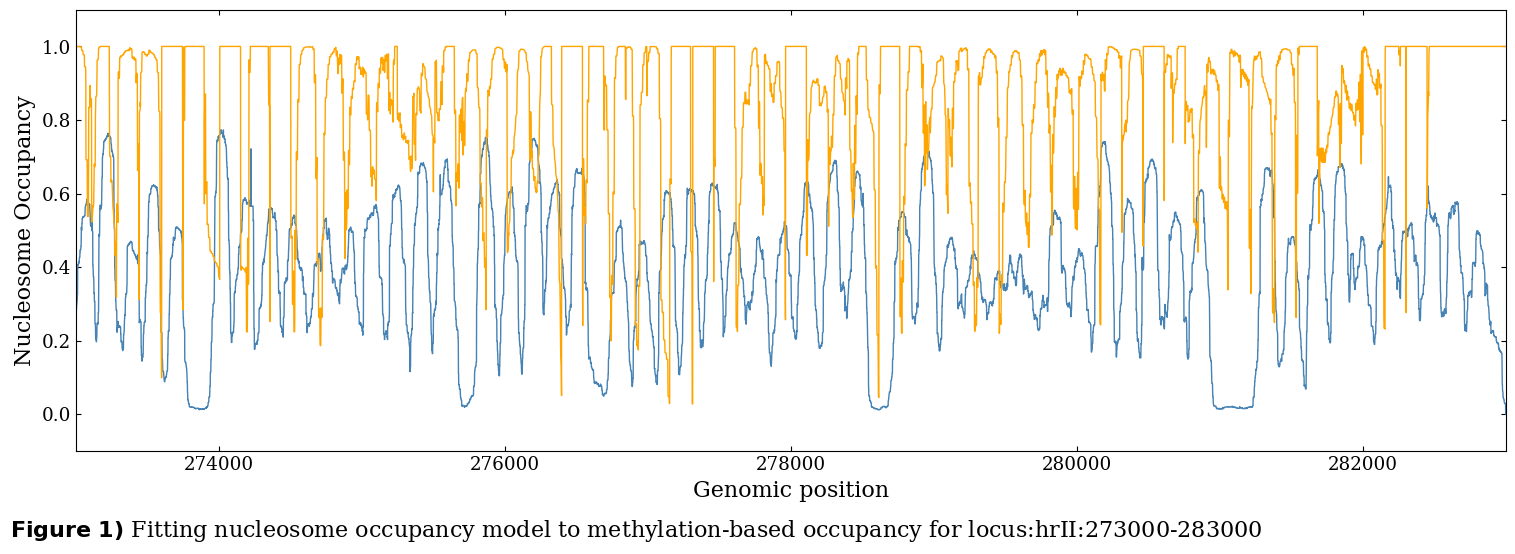

In [43]:
# period, amplitude, mu = result.params['period'].value, result.params['amplitude'].value, result.params['chemical_potential'].value
# fiber.calc_energy_landscape(period=period_lsq, amplitude=amplitude_lsq, chemical_potential=chemical_potential_lsq)
# lsq_occupancy = fiber.occupancy[1000:-1000]
fiber.calc_energy_landscape(period=period_fp, amplitude=amplitude_fp, chemical_potential=chemical_potential_fp)
cc_occupancy = fiber.occupancy[1000:-1000]
# test = np.cos(2 * np.pi * np.arange(len(occupancy)) / period + mu) * amplitude + result.params['offset'].value 
x_coords = np.arange(start, end)
plotter = Plotter(fig_size=(15, 5))
plotter.new(ncols=1, nrows=1)

ax1 = plotter.axes
ax1.plot(x_coords, occupancy, label=f"Observed occupancy", color="steelblue",linewidth=1)
ax1.plot(x_coords, cc_occupancy, label=f"Fitted occupancy, mu={chemical_potential_fp}, period={period_fp}, amp={amplitude_fp}", color="orange", linewidth=1)
# ax1.plot(x_coords, lsq_occupancy, label=f"LSQ Fitted occupancy, mu={chemical_potential_lsq}, period={period_lsq}, amp={amplitude_lsq}", color="green", linewidth=1)
ax1.set_xlabel("Genomic position")
ax1.set_ylabel("Nucleosome Occupancy")

# for orf in fiber.orfs:
#             name = orf["name"]
#             if orf["strand"] == -1:
#                 name = f"< {name}"
#                 top = 0
#                 bottom = -0.1
#             else:
#                 name = f"{name} >"
#                 top = 0
#                 bottom = -0.1

#             orf_start = min(orf["start"], orf["end"])
#             orf_end = max(orf["start"], orf["end"])
            
#             if orf_end < start or orf_start > end:
#                 continue

#             # clip to visible range
#             plot_start = max(orf_start, start)
#             plot_end = min(orf_end, end)

#             ax1.fill_between(
#                 [plot_start, plot_end],
#                 bottom,
#                 top,
#                 color="blue",
#                 alpha=0.5,
#                 label=orf["name"],
#             )

#             ax1.text(
#                 (plot_start + plot_end) / 2,
#                 -0.06,
#                 name,
#                 ha="center",
#                 va="center",
#                 fontsize=7,
#                 font='DejaVu Sans',
#                 weight="bold",
#                 color="white",
#             )

ax1.set_xlim(start, end)
ax1.set_ylim(-0.1, 1.1)
plotter.caption(f"Fitting nucleosome occupancy model to methylation-based occupancy for locus:{chrom}:{start}-{end}")
# plt.legend()

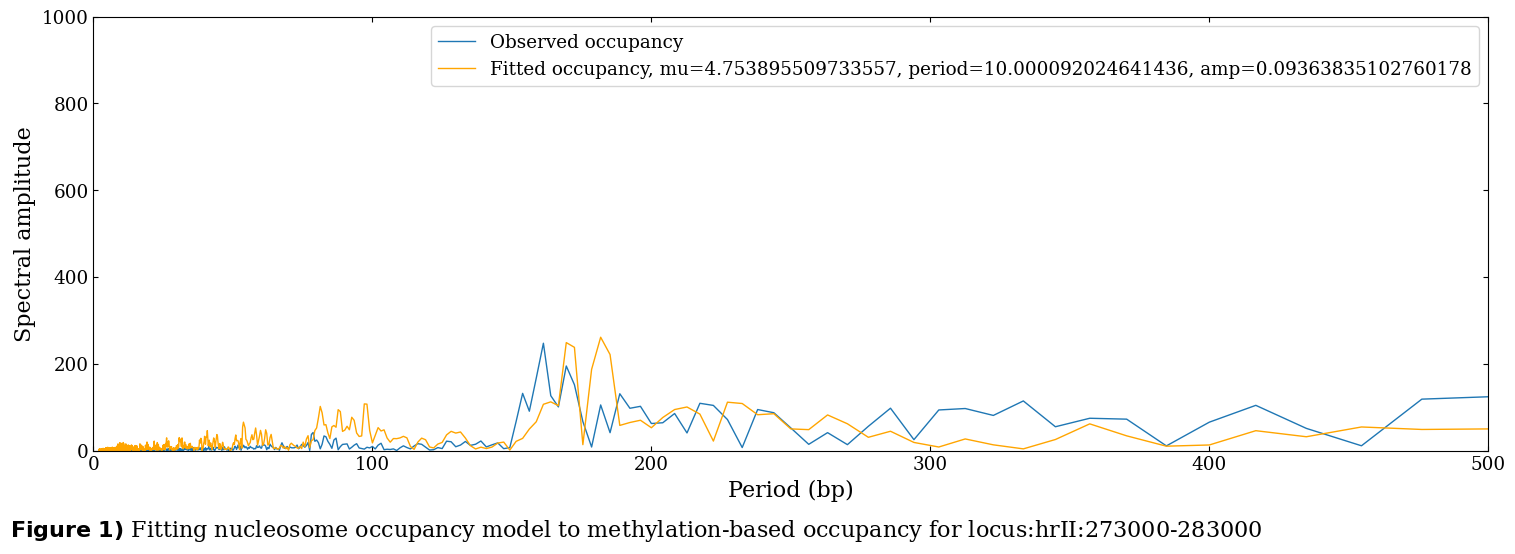

In [39]:
window = np.hanning(len(occupancy))
data_fft = rfft(occupancy * window)

# model_fft_lsq = rfft(lsq_occupancy * window)
model_fft_cc = rfft(cc_occupancy * window)

N = len(occupancy)
bins = np.arange(1, len(data_fft))  # skip DC bin 0

# Convert bins to period in bp for a more interpretable x-axis
periods = N / bins


plotter = Plotter(fig_size=(15, 5))
plotter.new(ncols=1, nrows=1)

ax1 = plotter.axes
ax1.plot(periods, np.abs(data_fft[1:]), label=f"Observed occupancy", linewidth=1)
# ax1.plot(periods, np.abs(model_fft_lsq[1:]), label=f"Fitted occupancy, mu={chemical_potential_lsq}, period={period_lsq}, amp={amplitude_lsq}", color="green", linewidth=1)
ax1.plot(periods, np.abs(model_fft_cc[1:]), label=f"Fitted occupancy, mu={chemical_potential_fp}, period={period_fp}, amp={amplitude_fp}", color="orange", linewidth=1)

ax1.set_xlabel("Period (bp)")
ax1.set_ylabel("Spectral amplitude")

ax1.set_xlim(0, 500)
ax1.set_ylim(0, 1000)
plotter.caption(f"Fitting nucleosome occupancy model to methylation-based occupancy for locus:{chrom}:{start}-{end}")
plt.legend()

<Axes: title={'center': 'Predicted vs. measured frfsm fit'}, xlabel='Measured occupancy', ylabel='Predicted occupancy'>

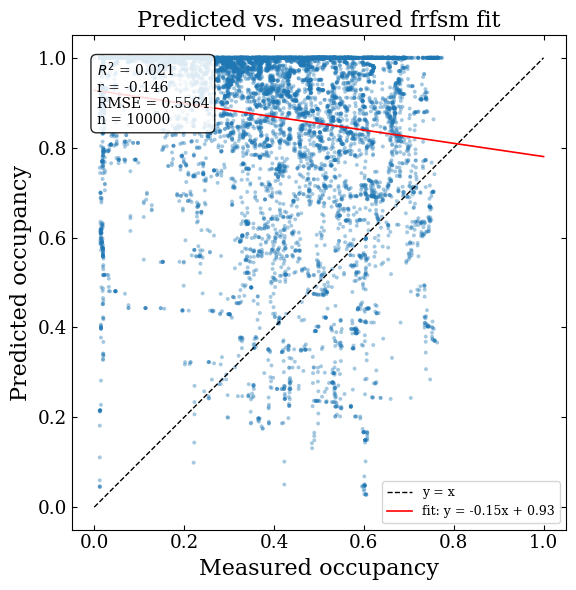

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_correlation(measured, predicted, ax=None, title=None):
    """
    Scatter plot of predicted vs measured values with R² and Pearson r.

    Parameters
    ----------
    measured : array-like
        Observed/experimental occupancy.
    predicted : array-like
        Model output (e.g. from model_func with fitted parameters).
    ax : matplotlib Axes, optional
        Existing axis to draw into. If None, a new figure is created.
    title : str, optional
    """
    measured = np.asarray(measured).ravel()
    predicted = np.asarray(predicted).ravel()

    if measured.shape != predicted.shape:
        raise ValueError(
            f"Shape mismatch: measured {measured.shape} vs predicted {predicted.shape}"
        )

    # Statistics
    r, p_value = pearsonr(measured, predicted)
    r_squared = r ** 2
    rmse = np.sqrt(np.mean((predicted - measured) ** 2))

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # Scatter
    ax.scatter(measured, predicted, s=8, alpha=0.4, edgecolor='none')

    # y = x reference line
    lo = min(measured.min(), predicted.min())
    hi = max(measured.max(), predicted.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='y = x')

    # Linear fit line
    slope, intercept = np.polyfit(measured, predicted, 1)
    xs = np.array([lo, hi])
    ax.plot(xs, slope * xs + intercept, 'r-', lw=1.2,
            label=f'fit: y = {slope:.2f}x + {intercept:.2f}')

    ax.set_xlabel('Measured occupancy')
    ax.set_ylabel('Predicted occupancy')
    ax.set_title(title or 'Predicted vs. measured frfsm fit')
    ax.set_aspect('equal', adjustable='box')

    # Annotation box with stats
    stats_text = (
        f'$R^2$ = {r_squared:.3f}\n'
        f'r = {r:.3f}\n'
        f'RMSE = {rmse:.4f}\n'
        f'n = {len(measured)}'
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    return ax

plot_correlation(occupancy, cc_occupancy)

(<Axes: title={'center': 'Phase correlation'}, xlabel='Lag (positions, predicted relative to measured)', ylabel='Normalized cross-correlation'>,
 np.int64(85),
 np.float64(0.23107112374796532))

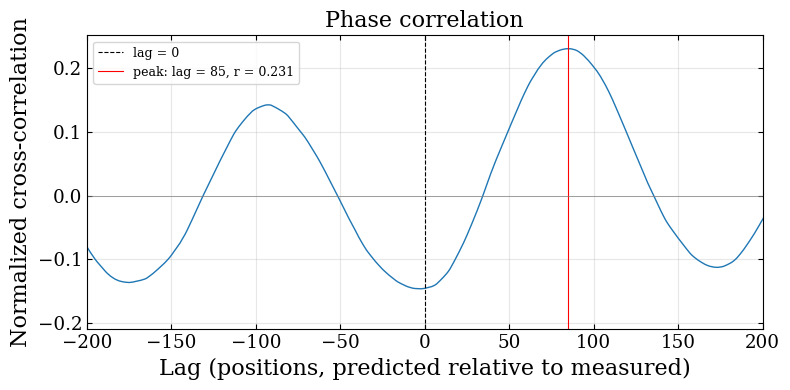

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate, correlation_lags

def plot_phase_correlation(measured, predicted, max_lag=None, ax=None, title=None):
    """
    Cross-correlation of predicted vs measured as a function of lag.

    A peak at lag=0 means the model is in phase with the data.
    A peak at lag=k means predictions are shifted by k positions
    relative to measurements (positive k = prediction lags behind).

    Parameters
    ----------
    measured : array-like
    predicted : array-like
    max_lag : int, optional
        Restrict the x-axis to ±max_lag. Useful for periodic data
        where you only care about sub-period shifts. If None, shows full range.
    ax : matplotlib Axes, optional
    title : str, optional
    """
    measured = np.asarray(measured, dtype=float).ravel()
    predicted = np.asarray(predicted, dtype=float).ravel()

    if measured.shape != predicted.shape:
        raise ValueError(
            f"Shape mismatch: measured {measured.shape} vs predicted {predicted.shape}"
        )

    # Mean-center so correlation reflects shape agreement, not DC offset
    m = measured - measured.mean()
    p = predicted - predicted.mean()

    # Full cross-correlation
    xcorr = correlate(p, m, mode='full')
    lags = correlation_lags(len(p), len(m), mode='full')

    # Normalize so peak = 1 means perfect linear agreement at that lag
    norm = np.sqrt(np.sum(m ** 2) * np.sum(p ** 2))
    if norm > 0:
        xcorr = xcorr / norm

    # Peak
    peak_idx = np.argmax(xcorr)
    peak_lag = lags[peak_idx]
    peak_val = xcorr[peak_idx]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(lags, xcorr, lw=1)
    ax.axvline(0, color='k', ls='--', lw=0.8, label='lag = 0')
    ax.axvline(peak_lag, color='r', ls='-', lw=0.8,
               label=f'peak: lag = {peak_lag}, r = {peak_val:.3f}')
    ax.axhline(0, color='gray', lw=0.5)

    if max_lag is not None:
        ax.set_xlim(-max_lag, max_lag)

    ax.set_xlabel('Lag (positions, predicted relative to measured)')
    ax.set_ylabel('Normalized cross-correlation')
    ax.set_title(title or 'Phase correlation')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()

    return ax, peak_lag, peak_val

plot_phase_correlation(occupancy, cc_occupancy, max_lag=200)